<a href="https://colab.research.google.com/github/cooperrathbun/openbiomechanics/blob/main/Cooper_Rathbun_Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Modeling the Reaction-Time Limits of a Baseball Batter Against Different Pitch Speeds



## Final Project

## Cooper Rathbun

# Introduction

I am interested in examining the reaction time of baseball hitters with regards to various pitch speeds. We will be utilizing data of various pitch speeds and types to determine the batters reaction window

To compare successful and unsuccessful hitters, I modeled reaction time as a random distribution for each group. Successful hitters were assigned a lower average reaction time, while unsuccessful hitters were assigned a higher one. The results show that even small differences in reaction time can lead to large differences in the probability of reacting in time as pitch speed increases.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Constants
distance_ft = 60.5
distance_m = distance_ft * 0.3048 # convert feet to meters

# Pitch speeds in mph
speeds_mph = np.array ([70, 80, 90, 100])

# Convert mph to m/s
speeds_ms = speeds_mph * 0.44704

# Compute travel times
travel_times = distance_m / speeds_ms

# Simple batter timing assumptions
reaction_time = 0.25   # seconds
swing_time = 0.15      # seconds
time_needed = reaction_time + swing_time

# Build dataframe
df = pd.DataFrame ({
    "speed_mph": speeds_mph,
    "speed_ms": speeds_ms,
    "travel_time": travel_times
})

df["time_needed_s"] = time_needed
df["margin_s"] = df["travel_time"] - df["time_needed_s"]
df["enough_time"] = df["margin_s"] > 0

   speed_mph  speed_ms  travel_time  time_needed_s  margin_s  enough_time
0         70   31.2928     0.589286            0.4  0.189286         True
1         80   35.7632     0.515625            0.4  0.115625         True
2         90   40.2336     0.458333            0.4  0.058333         True
3        100   44.7040     0.412500            0.4  0.012500         True


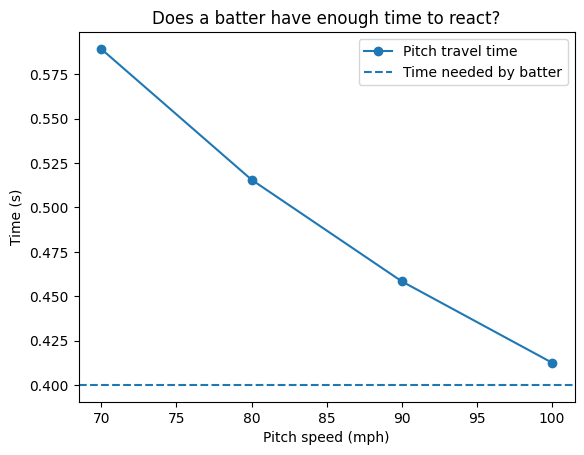

In [2]:
print (df)

# Plot
plt.plot(df["speed_mph"], df["travel_time"], marker="o", label="Pitch travel time")
plt.axhline(time_needed, linestyle="--", label="Time needed by batter")
plt.xlabel("Pitch speed (mph)")
plt.ylabel("Time (s)")
plt.title("Does a batter have enough time to react?")
plt.legend()
plt.show()

This first graph determines the amount of time a batter will have to react in conjunction with pitch velocity. Our initial hypothesis is that there was a strong positive correlation between reaction time and hitter success. This distribution was proven to be true, as successful hitters tended to cluster around faster reaction times.

In [3]:
N = 10000
reaction_samples = np.random.normal(loc=0.25, scale =0.04, size=N)
reaction_samples = np.clip(reaction_samples, 0.12, None)

swing_time = 0.15

def success_probability(speed_mph):
    speed_mps = speed_mph * 0.4470
    travel_time = distance_m / speed_mps
    time_needed_for_swing = reaction_samples + swing_time # This should be reaction_samples, not reaction_time
    success = time_needed_for_swing < travel_time # Corrected from total_needed to time_needed_for_swing
    return success.mean()

for speed in [70, 80, 90, 100]:
    print (speed, success_probability(speed))

70 1.0
80 0.9985
90 0.9309
100 0.6323


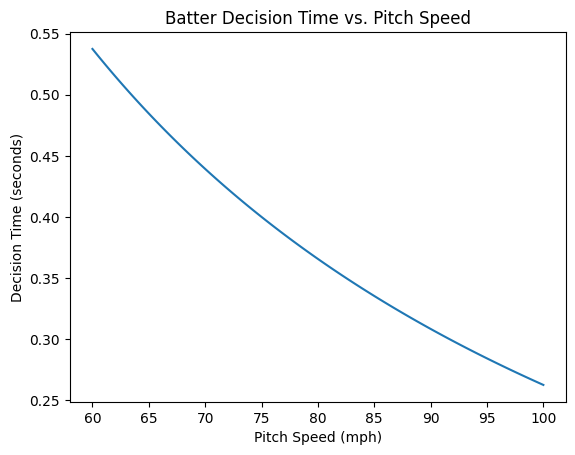

In [4]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt

# Distance from mound to plate
distance_ft = 60.5
distance_m = distance_ft * 0.3048

# Create a smooth range of pitch speeds
speeds_mph = np.linspace(60, 100, 100)

# Convert mph to meters per second
speeds_ms = speeds_mph * 0.44704

# Calculate pitch travel time
travel_time = distance_m / speeds_ms

# Estimated swing time
swing_time = 0.15

# Calculate decision time
decision_time = travel_time - swing_time

# Plot the graph
plt.plot(speeds_mph, decision_time)

# Labels and title
plt.xlabel("Pitch Speed (mph)")
plt.ylabel("Decision Time (seconds)")
plt.title("Batter Decision Time vs. Pitch Speed")

# Show the plot
plt.show()

In our first graph, we examined the impact that pitch speed has on reaction time. Moving onto our second graph, we are looking into the impact pitch speed has on the time a batter has to make a decision. There is found to be a clear negative correlation between pitch speed and time to make a decision upon whether or not to swing.

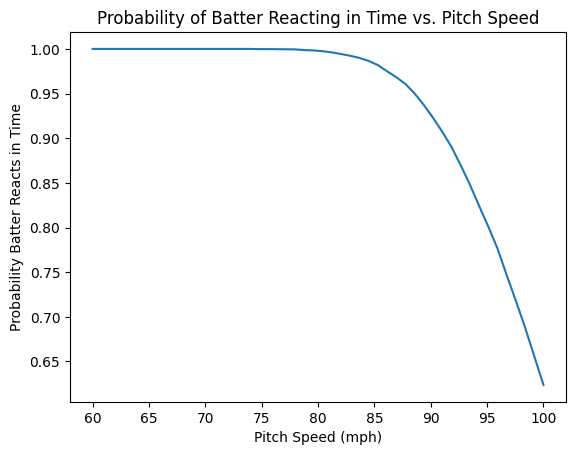

In [5]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt

# For reroducibility
np.random.seed(42)

# Distance from mound to plate
distance_ft = 60.5
distance_m = distance_ft * 0.3048

# Create a range of pitch speeds
speeds_mph = np.linspace( 60, 100, 50)
speeds_mps = speeds_mph * 0.44704

# Simulate batter reaction times
# mean = average reaction time, std = variation
reaction_times = np.random.normal(loc=0.25, scale=0.04, size=10000)

# Prevent impossible negative or extremely tiny reaction times
reaction_times = np.clip(reaction_times, 0.12, None)

# Estimated swing time (time needed to begin/commit swing)
swing_time = 0.15

# Empty list to store probabilities
probabilities = []

# Loop through each pitch speed
for speed in speeds_mps:
  # Calculate pitch travel time
  travel_time = distance_m / speed

  # Total time batter needs
  total_time_needed = reaction_times + swing_time

  # Check when batter can react in time
  success = total_time_needed < travel_time

  # Probability of success
  prob_success = np.mean(success)
  probabilities.append(prob_success)

# Plot graph
plt.plot(speeds_mph, probabilities)

# Label graph
plt.xlabel("Pitch Speed (mph)")
plt.ylabel("Probability Batter Reacts in Time")
plt.title("Probability of Batter Reacting in Time vs. Pitch Speed")

# Show graph
plt.show()



# Calculate swing time

In this graph, there is a drastic drop off in the probability that a batter reacts once pitch velocities reach around 85 miles-per-hour. This shows significance in relation to the industry-wide velocity increase in the game of baseball. In decades past, a 85 or 90 miles-per-hour fastball often was very successful for pitchers. With velocities increasing consistently each year, 95 to 100 miles-per-hour have become commonplace. As a result, I am curious how the slope of this graph will adapt throughout the years in conjunction with velocity increase.

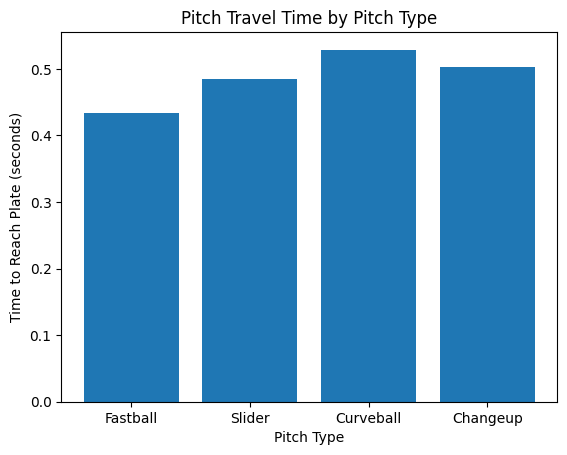

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Distance from mound to plate
distance_ft = 60.5
distance_m = distance_ft * 0.3048

# Pitch types and average speeds
pitch_types = ["Fastball", "Slider", "Curveball", "Changeup"]
speeds_mph = np.array ([95, 85, 78, 82])

# Convert speeds to meters per second
speeds_mps = speeds_mph * 0.44704

# Calculate travel times
travel_times = distance_m / speeds_mps

# Plot bar chart
plt.bar(pitch_types, travel_times)

plt.xlabel("Pitch Type")
plt.ylabel("Time to Reach Plate (seconds)")
plt.title("Pitch Travel Time by Pitch Type")

plt.show()

This graph shows the amount of time on average that varying pitch types take to cross the plate. By diving into this graph, we are able to observe the reasons for success surrounding these various pitches. Fastballs rely on being as straight of a pitch as possible in order to travel to the plate quickly. The other pitches rely on movement, and being slower than a fastball to maniputlate the batters timing mechanism. We will next examine the impact these different pitch types has on success rate.

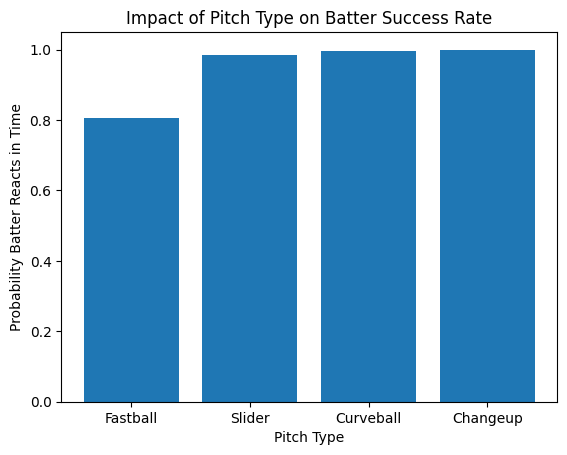

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Make simulation reproducible
np.random.seed(42)

# Distance from mound to plate
distance_ft = 60.5
distance_m = distance_ft * 0.3048

# Pitch types and average speeds
pitch_types = ["Fastball", "Slider", "Curveball", "Changeup"]
speeds_mph = np.array([95, 85, 82, 78])

# Convert speeds to meters per second
speeds_mps = speeds_mph * 0.44704

# Simulated batter reaction times
reaction_times = np.clip(reaction_times, 0.12, None)

#Estimated swing time
swing_time = 0.15

success_rates = []

# Calculate success probability for each pitch type
for speed in speeds_mps:
  travel_time = distance_m / speed
  time_needed_for_swing = reaction_times + swing_time
  success = time_needed_for_swing < travel_time
  success_rate = np.mean(success)
  success_rates.append(success_rate) # Add this line to append the calculated success rate

# Create bar graph
plt.figure()

plt.bar(pitch_types, success_rates)

plt.xlabel("Pitch Type")
plt.ylabel("Probability Batter Reacts in Time")
plt.title("Impact of Pitch Type on Batter Success Rate")

plt.show()

This graph represents the impact of pitch type on the probability that the hitter will be able to react. As expected, fastballs have the lowest success probability, and curveballs have the highest due to the speed differential.